In [ ]:
#!pip install coolprop
#!pip install devito

Operator `Kernel` ran in 0.27 s
INFO:Devito:Operator `Kernel` ran in 0.27 s
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


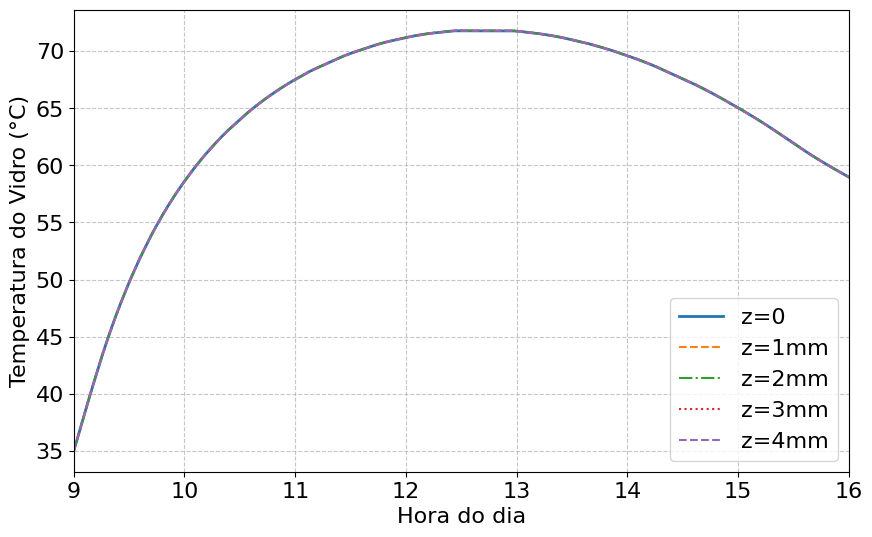

In [ ]:
import numpy as np
from devito import *
import matplotlib.pyplot as plt
import math
from examples.seismic.source import Receiver, TimeAxis
import CoolProp.CoolProp as CP

# ============================================================================
# BLOCO DA RADIAÇÃO
# ============================================================================
def deg2rad(x): return x * math.pi / 180.0
def rad2deg(x): return x * 180.0 / math.pi

def SolarDeclination(day_of_year):
    deg = 23.45 * math.sin(deg2rad(360.0 * (284 + day_of_year) / 365.0))
    return deg2rad(deg)

def hour_angle(hora_decimal):
    return deg2rad((hora_decimal - 12.0) * 15.0)

def sin_solar_altitude(latitude_deg, decl_rad, hour_ang_rad):
    i = deg2rad(latitude_deg)
    return math.cos(i) * math.cos(hour_ang_rad) * math.cos(decl_rad) + math.sin(i) * math.sin(decl_rad)

def direct_radiation(Ic, B, sinb):
    if sinb <= 0.0: return 0.0
    return Ic * math.exp(-B / sinb)

def FSS(tilt_deg):
    S = deg2rad(tilt_deg)
    return (1.0 + math.cos(S)) / 2.0

def diffuse_radiation(IDN, tilt_deg):
    C = 0.135
    return C * IDN * FSS(tilt_deg)

def Fsg(tilt_deg):
    S = deg2rad(tilt_deg)
    return (1.0 - math.cos(S)) / 2.0

def reflected_radiation(IDN, Idq, tilt_deg):
    krq = 0.2
    return (IDN + Idq) * krq * Fsg(tilt_deg)

#MODIFICADO: Atualizado para refletir a Equação 10 do artigo, extraindo o seno do azimute.
def sin_solar_azimuth(decl_rad, hour_ang_rad, sinb):
    cosb = math.sqrt(max(0.0, 1.0 - sinb**2))
    if abs(cosb) < 1e-8: return 0.0
    sin_phi = (math.cos(decl_rad) * math.sin(hour_ang_rad)) / cosb
    return max(-1.0, min(1.0, sin_phi))

#MODIFICADO: A função cos_incidence_full foi simplificada para refletir a Equação 9 rigorosamente.
def cos_incidence_eq9(sinb, sin_phi, tilt_deg):
    S = deg2rad(tilt_deg)
    cosb = math.sqrt(max(0.0, 1.0 - sinb**2))
    cos_phi = math.sqrt(max(0.0, 1.0 - sin_phi**2))
    term1 = cosb * cos_phi * math.sin(S)
    term2 = sinb * math.cos(S)
    return term1 + term2

def total_radiation(IDN, Idq, Irq, cosq):
    if cosq < 0: cosq = 0.0
    return IDN * cosq + Idq + Irq

def compute_It_series(time_seconds, latitude_deg=32, tilt_deg=37, day_of_year=200, Ic=1357.0, B=0.21):
    times = np.asarray(time_seconds)
    hours = (times / 3600.0)
    decl = SolarDeclination(day_of_year)
    It_series = np.zeros_like(hours)
    for idx, h in enumerate(hours):
        Hr = hour_angle(h)
        sinb = sin_solar_altitude(latitude_deg, decl, Hr)
        if sinb <= 0:
            It_series[idx] = 0.0
            continue
        IDN = direct_radiation(Ic, B, sinb)
        Idq = diffuse_radiation(IDN, tilt_deg)
        Irq = reflected_radiation(IDN, Idq, tilt_deg)

        #MODIFICADO: Utilização das novas funções alinhadas às Equações 9 e 10.
        sin_phi = sin_solar_azimuth(decl, Hr, sinb)
        cosq = cos_incidence_eq9(sinb, sin_phi, tilt_deg)

        It = total_radiation(IDN, Idq, Irq, cosq)
        It_series[idx] = It
    return It_series
# ============================================================================


# Coeficientes do vidro
k_g     = 5.9     # Condutividade Térmica do Vidro (W/m·K)
C_g     = 753     # Calor específico do vidro (J/kg·K)
ro_g    = 2466    # Densidade do Vidro (kg/m³)
delta_g = 4e-3    # Espessura do vidro (m) = 4mm
L       = 2       # Comprimento do coletor (m) — mantido para definir o grid
alpha_g = 0.1     # Absortividade optica do vidro (?)

# Grade de tempo simplificada
# MODIFICADO: Ajustado para iniciar às 9h e terminar às 16h (cortando o gráfico conforme pedido)
t0 = 9 * 3600
tn = 16 * 3600
dt = 0.1
nt = int((tn - t0) / dt)
time_range = TimeAxis(start=t0, stop=tn, num=nt+1)

# Discretização da malha
# nx=30
# nz=5: 5 pontos ao longo da espessura do vidro (z = 0, 1, 2, 3, 4 mm)
nx = 30
nz = 5

class Interior(SubDomain):
    name = 'interior'
    def define(self, dimensions):
        x, z = dimensions
        return {x: x, z: ('middle', 1, 1)}

# Grid 2D
x = SpaceDimension(name='x')
z = SpaceDimension(name='z')
grid = Grid(shape=(nx, nz), extent=(L, delta_g), dimensions=(x, z))

time = grid.time_dim    # guarda linha do tempo contínua ao invés de 2 instantes de tempo

dx, dz = grid.spacing
interior = Interior(grid=grid)

# Temperatura do vidro
TemperaturaVidro = TimeFunction(name='T_g',
                                grid=grid,
                                dimensions=(grid.time_dim, x, z),
                                save=nt+1, shape=(nt+1, nx, nz),
                                space_order=2)

# Condição inicial: 308.15 K (35°C) pra ser uniforme em todo o vidro
TemperaturaVidro.data_with_halo[:] = 308.15

# ----------------------------------------------------------------------------------------------------------------------------------------
segundos_do_dia = np.linspace(t0, tn, nt+1)    # Cria um vetor contendo todos os instantes de tempo discretizados (de t0 até tn)
It_series = compute_It_series(segundos_do_dia)     # Calcula a radiação solar (W/m²) p cada segundo gerado acima. O retorno é um array normal do Python

I_t_devito = Function(name='I_t', dimensions=(time,), shape=(nt+1,))    # devito trabalha de forma simbólica em C e não aceita arrays do Python direto na equação.
                                                                        # Então, declaramos uma função temporal oficial do Devito (dimensão 'time') para alocar memória

I_t_devito.data[:] = It_series    # Injeta os valores do array numérico (It_series) para dentro da estrutura de dados do Devito:

termo_radiacao = (I_t_devito * alpha_g) / (ro_g * C_g * delta_g)    # Termo fonte montado

# ----------------------------------------------------------------------------------------------------------------------------------------

eq11 = Eq(TemperaturaVidro.dt, ((k_g / (C_g * ro_g)) * TemperaturaVidro.dz2) + termo_radiacao)

eq_1 = Eq(TemperaturaVidro.forward, solve(eq11, TemperaturaVidro.forward), subdomain=interior)

# ----------------------------------------------------------------------------------------------------------------------------------------


# CONDIÇÕES DE CONTORNO COM COOLPROP ==========================

# MODIFICADO: A variável T_a constante foi removida pois agora o ar é dinâmico, mantido apenas o T_am
T_am = 308.15    # MANTIDO: 35°C de ar ambiente constante fora do secador (vento)

# Adicionado os parâmetros reais para o cálculo da convecção
P_atm = 101325
ro_a = 1.09        # Densidade do ar
a_duto = 0.1       # Altura do duto (m)
L_coletor = 2.0    # Comprimento do coletor (m)

# MODIFICADO: Cálculo correto da velocidade com base no fluxo de massa de 0.016 kg/s da Fig 4 do artigo.
mass_flow_ar = 0.016
Area_secao_transversal = a_duto * 1.0  # altura do duto * largura do coletor (assumida 1m)
VelocidadeAr = mass_flow_ar / (ro_a * Area_secao_transversal)

# temperatura de referência para propriedades do ar
T_ref = 308.15

# Puxando propriedades do Coolprop
viscosidadeDinamica = CP.PropsSI("V", "T", T_ref, "P", P_atm, "Air")
calorEspecifico = CP.PropsSI("CPMASS", "T", T_ref, "P", P_atm, "Air")
condutividadeTermica = CP.PropsSI("CONDUCTIVITY", "T", T_ref, "P", P_atm, "Air")

Re = ro_a * VelocidadeAr * L_coletor / viscosidadeDinamica
Pr = calorEspecifico * viscosidadeDinamica / condutividadeTermica

# Calculando h_ga (Convecção interna) usando eq 14 do artigo
if Re * Pr * (a_duto / L_coletor) > 70:
    Nu = 7.6
else:
    Nu = 1.85 * (Re * Pr * a_duto / L_coletor)**(1/3)
h_ga = Nu * condutividadeTermica / a_duto

# Calculando h_gam (Convecção externa) usando eq 19 do artigo
Nu_gam = 0.86 * (Re**0.5) * (Pr**(1/3))
h_gam = Nu_gam * condutividadeTermica / L_coletor

# ========================================================================================
# ADICIONADO: Propriedades da Placa Absorvedora e Geometria extra
# ========================================================================================
tau_g   = 0.96       # Transmitância do vidro (estimado do artigo/apêndice)
alpha_p = 0.8        # Absortividade da placa (estimado do apêndice)
ro_p    = 2700       # Densidade da placa (kg/m³) - assumido como Alumínio/Aço provisório
C_p     = 900        # Calor específico da placa (J/kg.K)
l_p     = 0.002      # Espessura da placa (m)
A_c     = L_coletor * 1.0  # Área do coletor (m²) assumindo largura = 1m
b_duto  = a_duto     # 'b' na Equação 13 é a altura do duto

h_pa    = h_ga       # MODIFICADO: O artigo indica que h_pa usa a mesma Equação 14 que o h_ga

# ========================================================================================
# ADICIONADO: Fórmulas de Radiação Não-Lineares (Eq 15 e Equação Fantasma h_rpg)
# ========================================================================================
sigma = 5.67e-8  # Constante de Stefan-Boltzmann (W/m²K⁴)
eps_p = 0.8      # Emissividade da placa (Suposição com base no alpha_p)
eps_g = 0.9      # Emissividade do vidro (Suposição literária padrão)

# Eq. de T_sky baseada na temperatura ambiente constante (Eq 15 do artigo)
T_sky = 0.0552 * (T_am)**1.5

# ========================================================================================
# ADICIONADO: Matrizes Temporais Dinâmicas para Ar e Placa (Dimensões: time, x)
# ========================================================================================
# O space_order=1 permite o uso do operador de advecção upwind (.dxl) no ar
TemperaturaAr = TimeFunction(name='T_a_dyn', grid=grid, dimensions=(time, x),
                             save=nt+1, shape=(nt+1, nx), space_order=1)
TemperaturaPlaca = TimeFunction(name='T_p_dyn', grid=grid, dimensions=(time, x),
                                save=nt+1, shape=(nt+1, nx), space_order=1)

# Condições iniciais (Tudo começa na temperatura ambiente)
TemperaturaAr.data_with_halo[:] = T_am
TemperaturaPlaca.data_with_halo[:] = T_am

# ========================================================================================
# ADICIONADO: Equação 12 (Placa Absorvedora) com radiação não-linear
# ========================================================================================
# As funções dinâmicas de radiação são calculadas simbolicamente a cada passo do Devito
h_rpsky_dyn = (sigma * (TemperaturaPlaca**2 + T_sky**2) * (TemperaturaPlaca + T_sky)) / ((1/eps_p) + (1/eps_g) - 1)
h_rpg_dyn = (sigma * (TemperaturaPlaca**2 + TemperaturaVidro[time, x, 0]**2) * (TemperaturaPlaca + TemperaturaVidro[time, x, 0])) / ((1/eps_p) + (1/eps_g) - 1)

termo_rad_placa = (I_t_devito * tau_g * alpha_p) / (ro_p * C_p * l_p)

# MODIFICADO: Substituição das constantes h_rpsky e h_rpg pelas expressões simbólicas dinâmicas

eq12 = Eq(TemperaturaPlaca.dt,
          termo_rad_placa
          + (h_pa / (ro_p * C_p * l_p)) * (TemperaturaAr - TemperaturaPlaca)
          - (h_rpsky_dyn / (ro_p * C_p * l_p)) * (TemperaturaPlaca - T_sky)
          - (h_rpg_dyn / (ro_p * C_p * l_p)) * (TemperaturaPlaca - TemperaturaVidro[time, x, 0]))

eq_placa = Eq(TemperaturaPlaca.forward, solve(eq12, TemperaturaPlaca.forward))

# ========================================================================================
# ADICIONADO: Equação 13 (Ar Passante) - COM CORREÇÃO ro_a * C_a
# ========================================================================================
# Nota: TemperaturaAr.dxl aplica a diferença finita atrasada (upwind) ideal para advecção

eq13 = Eq(TemperaturaAr.dt,
          - VelocidadeAr * TemperaturaAr.dxl
          + (h_ga * b_duto / (ro_a * calorEspecifico * A_c)) * (TemperaturaVidro[time, x, 0] - TemperaturaAr) *200
          + (h_pa * b_duto / (ro_a * calorEspecifico * A_c)) * (TemperaturaPlaca - TemperaturaAr) * 200)

eq_ar = Eq(TemperaturaAr.forward, solve(eq13, TemperaturaAr.forward))

# ADICIONADO: Condição de contorno do Ar (Ar entra no coletor em x=0 à temperatura ambiente)
bc_ar = Eq(TemperaturaAr[time+1, 0], T_am)

# ========================================================================================
# MODIFICADO: Equação 17 e 18 lendo a TemperaturaAr dinâmica no tempo e em x
eq_topo = Eq(TemperaturaVidro[time+1, x, 0],
             (k_g * TemperaturaVidro[time, x, 1] + h_ga * dz * TemperaturaAr[time, x]) / (k_g + h_ga * dz))

eq_fundo = Eq(TemperaturaVidro[time+1, x, nz-1],
              (k_g * TemperaturaVidro[time, x, nz-2] + h_gam * dz * T_am) / (k_g + h_gam * dz))
# ========================================================================================

# MODIFICADO: Inserido eq_placa, eq_ar e bc_ar no Operador para acoplamento dinâmico
op = Operator([eq_placa, eq_ar, bc_ar, eq_topo, eq_1, eq_fundo])

op(dt=dt, time_M=nt-1)

horas_eixo_x = segundos_do_dia / 3600.0

# ========================================================================================
# MODIFICADO: Nova Plotagem da Figura 4 - Extração dos dados no ponto final do coletor (x = nx - 1)
# Subtraído 273.15 para plotar em Graus Celsius e ficar comparável com o artigo
# ========================================================================================
T_z0 = TemperaturaVidro.data[:, -1, 0] - 273.15
T_z1 = TemperaturaVidro.data[:, -1, 1] - 273.15
T_z2 = TemperaturaVidro.data[:, -1, 2] - 273.15
T_z3 = TemperaturaVidro.data[:, -1, 3] - 273.15
T_z4 = TemperaturaVidro.data[:, -1, 4] - 273.15

plt.figure(figsize=(10, 6))
# Plotando as 5 espessuras ao longo do tempo
plt.plot(horas_eixo_x[:-1], T_z0[:-1], label="z=0", linewidth=2.0)
plt.plot(horas_eixo_x[:-1], T_z1[:-1], label="z=1mm", linestyle='--')
plt.plot(horas_eixo_x[:-1], T_z2[:-1], label="z=2mm", linestyle='-.')
plt.plot(horas_eixo_x[:-1], T_z3[:-1], label="z=3mm", linestyle=':')
plt.plot(horas_eixo_x[:-1], T_z4[:-1], label="z=4mm", linestyle='--')

plt.xlim([9, 16])
plt.xlabel("Hora do dia")
plt.ylabel("Temperatura do Vidro (°C)")
#plt.title("Réplica da Fig. 4 do Artigo - Temperatura no Ponto Final do Coletor")
plt.ticklabel_format(useOffset=False, style='plain')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

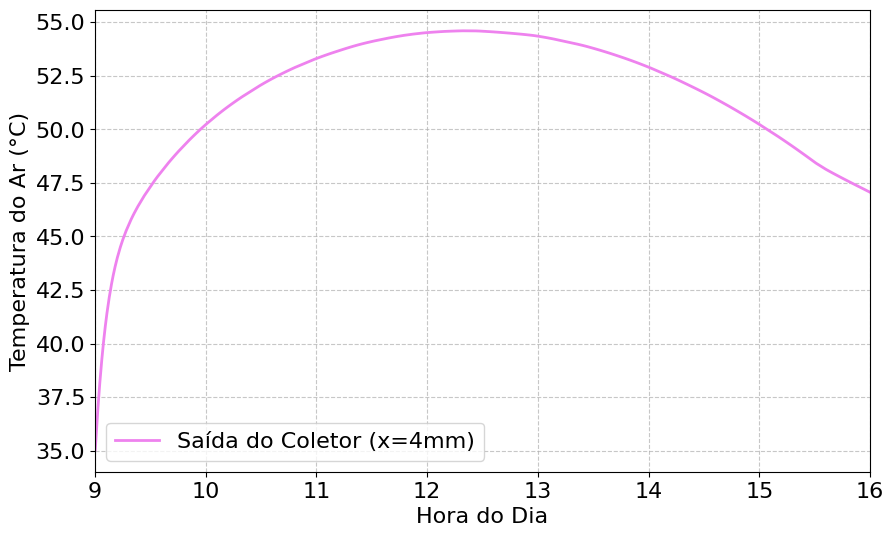

In [ ]:
# Extraindo a temperatura do ar no ponto de saída (último índice em x)
T_ar_saida = TemperaturaAr.data[:, -1] - 273.15

plt.figure(figsize=(10, 6))
plt.plot(horas_eixo_x[:-1], T_ar_saida[:-1], color='violet', linewidth=2.0, label="Saída do Coletor (x=4mm)")

plt.xlim([9, 16])
plt.xlabel("Hora do Dia")
plt.ylabel("Temperatura do Ar (°C)")
#plt.title("Temperatura do Ar na Saída do Coletor vs. Tempo")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
ConteudoUmido = TimeFunction(name='U',
                       grid=grid,
                       dimensions=(time, x),
                       save=nt+1, shape=(nt+1, nx),
                       space_order=2)

TemperaturaMaterial = TimeFunction(name='T_m',
                       grid=grid,
                       dimensions=(time, x),
                       save=nt+1, shape=(nt+1, nx),
                       space_order=2)

M_0 = 3.5 #(g_água/g_material seco) Conteúdo úmido inicial
ConteudoUmido.data_with_halo[:] = M_0
TemperaturaMaterial.data_with_halo[:] = T_am

In [ ]:
D_e = 1610      #Energia de ativação do material sendo seco
D_r = 1.36e-7   #Coeficiente da equação diferencial
D = D_r * exp(-D_e/TemperaturaMaterial)  #Coeficiente difuso de transferência de massa
D_0 = D_r * math.exp(-D_e/T_ref)

eq_20 = Eq(ConteudoUmido.dt,
           D*ConteudoUmido.dx2)

C_m = 0.008*ConteudoUmido + 0.20  #Capacidade de calor do material
k_m = 0.00493*ConteudoUmido + 0.148 #Coeficiente de condutividade do material
ro_d = 960 #(kg*m^-3) Densidade do material seco
ro_w = 1000 #Densidade da água
epsilon = 4e-3 #Espessura do material sendo secado. "Banana slices were prepared first by peeling the skin and then slicing in 4-mm thick-ness and approximately of same diameter." (Karim; Hawlander, 2004)

entalpiaVap = CP.PropsSI('H', 'T', 273 + 50, 'Q', 1, 'Water')
entalpiaLiq = CP.PropsSI('H', 'T', 273 + 50, 'Q', 0, 'Water')
h_fg = entalpiaVap - entalpiaLiq #Entalpia de evaporação.

ro_m0 = ro_d * (1 + M_0)   #Densidade inicial do material
f = ro_d/ro_w
gamma = f/(1+f*M_0)
A = 1/(1+f*M_0)
ro_m = ro_m0*(ConteudoUmido+1)/((M_0+1)*(A+gamma*ConteudoUmido))
alpha_m = k_m/(ro_m*C_m)

eq_21 = Eq(TemperaturaMaterial.dt,
           alpha_m*TemperaturaMaterial.dx2)

In [ ]:
RegimeTurbulento = 3000        #Valor limite entre regime laminar e regime turbulento
Sc = viscosidadeDinamica/D     #Número de Schimidt

if Re < RegimeTurbulento:
  Sh = 0.332 * pow(Re, 1/2) * pow(Sc, 1/3)
else:
  Sh = 0.0296 * pow(Re, 1/2) * pow(Sc, 1/3)   #A equação utilizada pelo Hatami é diferente daquela apontada na refêrencia

h_m = Sh * D_0 / L              #Coeficiente de transfêrencia de massa

Nu_ma = 0.37*pow(Re, 3/5)
h_ma = Nu_ma * condutividadeTermica / epsilon

M_e = 0.23     #Equilíbrio do conteúdo úmido. Observando a fig. 11 e estimando. Também pode ser obtido a partir de Karim; Hawlader, 2004

In [ ]:
eqContorno1 = Eq(TemperaturaMaterial[time, 0],
                 TemperaturaMaterial[time, 1])

eqContorno2 = Eq(ConteudoUmido[time, 0],
                 ConteudoUmido[time, 1])

eqContorno3 = Eq(ConteudoUmido[time, nx-1],
                 (ConteudoUmido[time, nx-2] * D + h_m * dx * M_e)/(D + h_m * dx))

eqContorno4 = Eq(TemperaturaMaterial[time, nx-1],
                 TemperaturaMaterial[time, nx-2]
                 + (dx/k_m) * (h_ma * (TemperaturaAr[time,0] - TemperaturaMaterial[time, 0])
                              - h_m * ro_m * h_fg * (ConteudoUmido[time, nx-1] - M_e))
                 )

In [ ]:
op = Operator([eq_20, eq_21, eqContorno1, eqContorno2, eqContorno3, eqContorno4])

op(dt=dt, time_M=nt-1)

FAILED compiler invocation: gcc -march=native -O3 -g -fPIC -Wall -std=c99 -Wno-unused-result -Wno-unused-variable -Wno-unused-but-set-variable -ffast-math -shared -fopenmp /tmp/devito-jitcache-uid0/9d954977c1008e8e4a37680219e024b7b073d185.c -lm -o /tmp/devito-jitcache-uid0/9d954977c1008e8e4a37680219e024b7b073d185.so


CompileError: module compilation failed